In [1]:
import xarray as xr
from pathlib import Path

import numpy as np

In [2]:
data_folder = Path("./eso4clima/watervapor/")

## Monthly data watervapor

### Monthly data full

In [3]:
file_name = data_folder / "202001_mon_ERA5_full_prw.nc"
ds_monthly_full = xr.open_dataset(file_name)

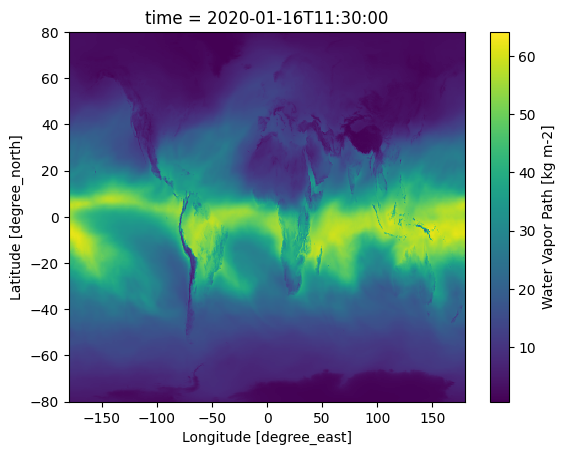

In [4]:
ds_monthly_full["prw"].plot()

In [5]:
# Check NaN values
np.isnan(ds_monthly_full["prw"]).sum()

<xarray.DataArray 'prw' ()> Size: 8B
array(0)
Attributes: (12/33)
    standard_name:                            atmosphere_mass_content_of_wate...
    long_name:                                Water Vapor Path
    units:                                    kg m-2
    cell_methods:                             time: mean
    GRIB_paramId:                             137
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Total column vertically-integra...
    GRIB_shortName:                           tcwv
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2
    GRIB_surface:                             0.0

### Monthly data masked

In [6]:
file_name = data_folder / "202001_mon_ERA5_masked_prw.nc"
ds_monthly_masked = xr.open_dataset(file_name)

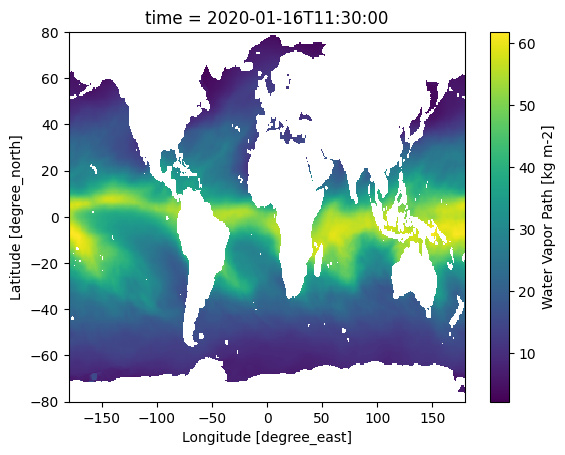

In [7]:
ds_monthly_masked["prw"].plot()

In [8]:
# Check NaN values along lat and lon dimensions
flag_sumlat = np.isnan(ds_monthly_masked["prw"].sum(dim="lat")).sum().values
flag_sumlon = np.isnan(ds_monthly_masked["prw"].sum(dim="lon")).sum().values

print(f"Nr. of longitude locations where all values are NaN: {flag_sumlat}")
print(f"Nr. of latitude locations where all values are NaN: {flag_sumlon}")

Nr. of longitude locations where all values are NaN: 0
Nr. of latitude locations where all values are NaN: 0


## Daily data 

### Daily data full

In [9]:
file_name = data_folder / "202001_day_ERA5_full_prw.nc"
ds_daily_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})

/tmp/ipykernel_10751/3417699456.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_daily_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})
/tmp/ipykernel_10751/3417699456.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_daily_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})


In [10]:
ds_daily_full

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 31, bnds: 2, lat: 320, lon: 720)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01T11:30:00 ... 2020-01-31T...
  * lat        (lat) float32 1kB 79.75 79.25 78.75 ... -78.75 -79.25 -79.75
  * lon        (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 496B dask.array<chunksize=(1, 2), meta=np.ndarray>
    prw        (time, lat, lon) float32 29MB dask.array<chunksize=(1, 160, 160), meta=np.ndarray>
Attributes:
    CDI:                     Climate Data Interface version 2.2.4 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Jul 06 10:02:21 2026: cdo daymean /work/bd08...
    regrid_method:           bilinear
    frequency:               day
    CDO:                     Climate Data Operators version 2.2.2 (https://mp...

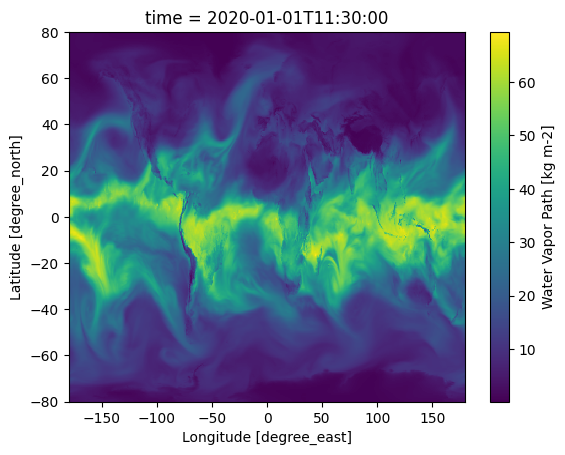

In [11]:
ds_daily_full["prw"].isel(time=0).plot()

In [12]:
ds_daily_full["prw"]

<xarray.DataArray 'prw' (time: 31, lat: 320, lon: 720)> Size: 29MB
dask.array<open_dataset-prw, shape=(31, 320, 720), dtype=float32, chunksize=(1, 160, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01T11:30:00 ... 2020-01-31T11...
  * lat      (lat) float32 1kB 79.75 79.25 78.75 78.25 ... -78.75 -79.25 -79.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes: (12/33)
    standard_name:                            atmosphere_mass_content_of_wate...
    long_name:                                Water Vapor Path
    units:                                    kg m-2
    cell_methods:                             time: mean
    GRIB_paramId:                             137
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Total column vertically-integra...
    GRIB_shortName:                           tcwv
    GRIB_totalNumber:                         0
    GRIB_units:                               kg m**-2
    GRIB_surface:                             0.0

In [13]:
# Check NaN values
nr_nans = np.isnan(ds_daily_full["prw"]).sum().values
nr_nans

array(0)

### Daily data masked

In [14]:
file_name = data_folder / "202001_day_ERA5_masked_prw.nc"
ds_daily_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})

/tmp/ipykernel_10751/546544133.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_daily_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})
/tmp/ipykernel_10751/546544133.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_daily_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})


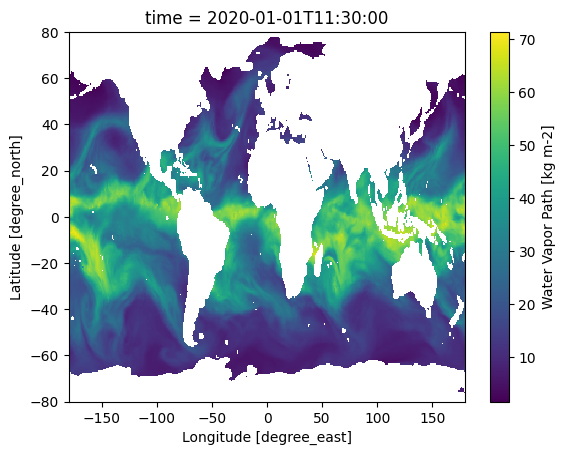

In [15]:
ds_daily_masked["prw"].isel(time=0).plot()

In [16]:
# Check NaN values along lat and lon dimensions
flag_sumlat = np.isnan(ds_daily_masked["prw"].sum(dim="lat")).sum().values
flag_sumlon = np.isnan(ds_daily_masked["prw"].sum(dim="lon")).sum().values

print(f"Nr. of longitude locations where all values are NaN: {flag_sumlat}")
print(f"Nr. of latitude locations where all values are NaN: {flag_sumlon}")

Nr. of longitude locations where all values are NaN: 0
Nr. of latitude locations where all values are NaN: 0


## Hourly data

### Hourly data full

In [17]:
file_name = data_folder / "202001_hr_ERA5_full_prw.nc"
ds_hourly_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})

/tmp/ipykernel_10751/1266915119.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_hourly_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})
/tmp/ipykernel_10751/1266915119.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_hourly_full = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})


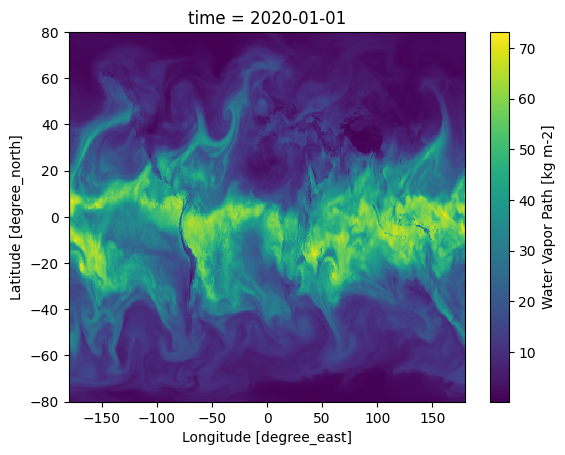

In [18]:
ds_hourly_full["prw"].isel(time=0).plot()

In [19]:
# Check NaN values
nr_nans = np.isnan(ds_hourly_full["prw"].sum("time", skipna=False)).sum().values
nr_nans

array(0)

### Hourly data masked

In [20]:
file_name = data_folder / "202001_hr_ERA5_masked_prw.nc"
ds_hourly_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})

/tmp/ipykernel_10751/331504258.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_hourly_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})
/tmp/ipykernel_10751/331504258.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 160. This could degrade performance. Instead, consider rechunking after loading.
  ds_hourly_masked = xr.open_dataset(file_name, chunks={"time": 1, "lat": 160, "lon": 160})


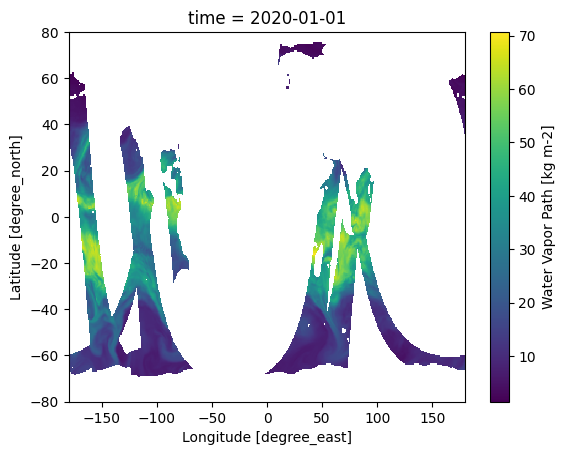

In [21]:
ds_hourly_masked["prw"].isel(time=0).plot()

In [22]:
# Check NaN values along lat and lon dimensions
flag_sumlat = np.isnan(ds_hourly_masked["prw"].sum(dim="time").sum(dim="lat")).sum().values
flag_sumlon = np.isnan(ds_hourly_masked["prw"].sum(dim="time").sum(dim="lon")).sum().values

print(f"Nr. of longitude locations where all values are NaN: {flag_sumlat}")
print(f"Nr. of latitude locations where all values are NaN: {flag_sumlon}")

Nr. of longitude locations where all values are NaN: 0
Nr. of latitude locations where all values are NaN: 0
